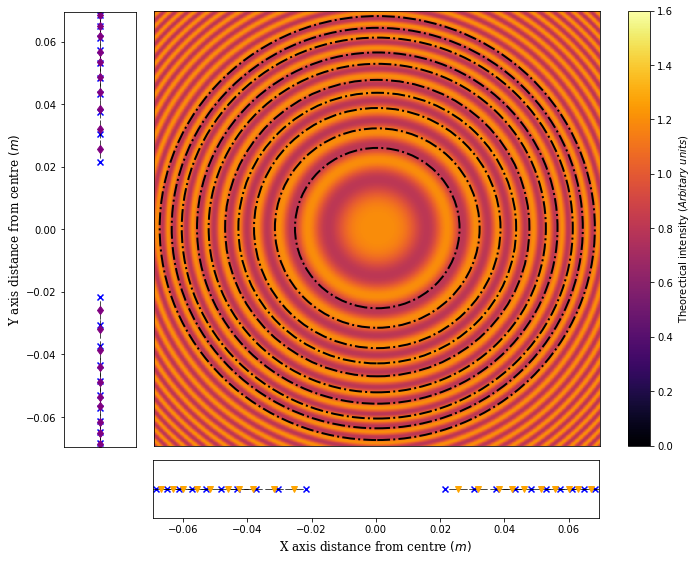

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col_T = 'blue'
ff = 'serif'
fs = 12

plt.rcParams['figure.figsize'] = [10,8]

Radii = [0.05125,0.06375,0.07675,0.0865,0.09475,0.105,0.11225,0.12175,0.128,0.1355]
scale = 0.0695

# generate 2 2d grids for the x & y bounds
y, x = np.meshgrid(np.linspace(-scale, scale, 1000), np.linspace(-scale, scale, 1000))

z = 1+ 0.2*np.cos(((2*np.pi)/((589.4570706*(10**-9)*11.08)))*((x**2+y**2)/8.5**2))

z = z[:-1, :-1]
z_min, z_max = 0, 1.6


fig, ax = plt.subplots()

c = ax.pcolormesh(x, y, z, cmap='inferno', vmin=z_min, vmax=z_max)
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])


#######################################################################################################################

sp = pd.read_excel('NR_P_FIX7.xlsx')
x_variable = np.array([0.021626,0.030584,0.037458,0.043252,0.048358,0.052973,0.057218,0.061168,0.064879,0.068388]) #THEORY
invx = -1*np.array([0.021626,0.030584,0.037458,0.043252,0.048358,0.052973,0.057218,0.061168,0.064879,0.068388])


y1_variable = np.array([0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5])

y2_variable = sp['T_Mean P1'].values
invy2_variable = -1*sp['T_Mean P1'].values
y2_error = sp['T_Error_P1'].values

y3_variable = sp['T_Mean P2'].values
invy3_variable = -1*sp['T_Mean P2'].values
y3_error = sp['T_Error_P2'].values

plt.gca().axes.get_xaxis().set_ticks([])
plt.gca().axes.get_yaxis().set_ticks([])

plt.figure(1).add_axes((0.123,-0.0005,0.62,0.1))
plt.errorbar(y2_variable, y1_variable, xerr = y2_error, fmt = 'v', color = 'orange', ecolor = 'black', capsize = 0.1, elinewidth = 0.7)
plt.errorbar(invy2_variable, y1_variable, xerr = y2_error, fmt = 'v', color = 'orange', ecolor = 'black', capsize = 0.1, elinewidth = 0.7)
plt.gca().set_xlim([-scale,scale])
plt.xlabel('X axis distance from centre$\ (m)$', family = ff, fontsize = fs)

plt.gca().axes.get_yaxis().set_ticks([])
plt.scatter(x_variable, y1_variable, marker = 'x', color = col_T)
plt.scatter(invx, y1_variable, marker = 'x', color = col_T)

plt.figure(1).add_axes((-0.0005,0.123,0.1,0.755))
plt.errorbar(y1_variable, y3_variable, yerr = y3_error, fmt = 'd', color = 'purple', ecolor = 'black', capsize = 0, elinewidth = 0.7)
plt.errorbar(y1_variable, invy3_variable, yerr = y3_error, fmt = 'd', color = 'purple', ecolor = 'black', capsize = 0.1, elinewidth = 0.7)
plt.gca().set_ylim([-scale,scale])
plt.ylabel('Y axis distance from centre$\ (m)$', family = ff, fontsize = fs)

plt.gca().axes.get_xaxis().set_ticks([])
plt.scatter(y1_variable, x_variable, marker = 'x', color = col_T)
plt.scatter(y1_variable, invx, marker = 'x', color = col_T)
#########################################################################################################################

plt.colorbar(c, ax=ax, label = 'Theorectical intensity $(Arbitary \ units)$')

for i in range (len(Radii)):
    t = plt.Circle((0,0), radius = Radii[i]/2, color = 'black', fill = False, ls = '-.', linewidth = 2)
    ax.add_patch(t)


#########################################################################################################################
#residuals_p1 = x_variable - y2_variable
#residuals_p2 = x_variable - y3_variable

#r1 = residuals_p1/(np.std(residuals_p1))
#r2 = residuals_p2/(np.std(residuals_p2))

#plt.figure(1).add_axes((0.25,-0.2,0.2,0.2))
#plt.title("Normalised Residuals \n Data Set 1", family = ff)
#plt.hist(r1, color = 'orange')
#plt.ylabel("Occurence", family = ff)

#plt.figure(1).add_axes((0.45,-0.25,0.2,0.2))
#plt.title("Normalised Residuals \n Data Set 2", family = ff)
#plt.hist(r2, color = 'purple')
#plt.gca().axes.get_yaxis().set_ticks([])

#########################################################################################################################

plt.show()

#fig.savefig('Theory2.png', dpi=fig.dpi, bbox_inches='tight', pad_inches=0.5)

